In [1]:
import torchvision
import torch.nn as nn
import torch
import torch.nn.functional as F
from torchvision import transforms,models,datasets
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from torch import optim
device = 'cuda' if torch.cuda.is_available() else 'cpu'
import cv2, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from glob import glob #imports

In [2]:
print(f"We are using {device} for training") #print

We are using cuda for training


In [3]:
train_data_dir = 'data/archive/training_set/training_set/'
test_data_dir = 'data/archive/test_set/test_set/' #caminho dos arquivos dos dados

In [4]:
from torch.utils.data import DataLoader, Dataset
class cats_dogs(Dataset):
    def __init__(self, folder):
        cats = glob(folder+'/cats/*.jpg')
        dogs = glob(folder+'/dogs/*.jpg')
        self.fpaths = cats + dogs #pega as fotos de cachorros e gatos
        from random import shuffle, seed; seed(10); shuffle(self.fpaths)
        self.targets = [fpath.split('/')[-1].startswith('dog') for fpath in self.fpaths] 
    def __len__(self): return len(self.fpaths) #qntd de imagens 
    def __getitem__(self, ix): #pega uma imagem pelo indice
        f = self.fpaths[ix]
        target = self.targets[ix]
        im = (cv2.imread(f)[:,:,::-1])
        im = cv2.resize(im, (224,224))
        return torch.tensor(im/255).permute(2,0,1).to(device).float(), torch.tensor([target]).float().to(device)

In [5]:
data = cats_dogs(train_data_dir) #cria o dataset de treino com as imagens
im, label = data[200] #pega uma imagem

tensor([1.], device='cuda:0')


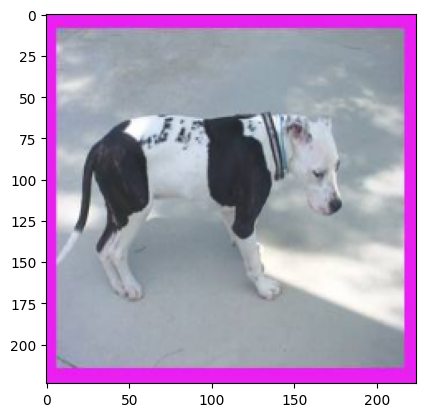

In [6]:
plt.imshow(im.permute(1,2,0).cpu())
print(label) #mostra a imagem

In [7]:
def conv_layer(ni,no,kernel_size,stride = 1):
    return nn.Sequential(
    nn.Conv2d(ni, no, kernel_size, stride), #camada de convolucao
    nn.ReLU(), #ativacao
    nn.BatchNorm2d(no), #normalizacao pra passar pra proxima camada
    nn.MaxPool2d(2) #pooling
    )
def get_model():
    model = nn.Sequential(
    conv_layer(3, 64, 3),
    conv_layer(64, 512, 3),
    conv_layer(512, 512, 3),
    conv_layer(512, 512, 3),
    conv_layer(512, 512, 3),
    conv_layer(512, 512, 3), #camadas convolcuionais
    nn.Flatten(), #joga pra um vetor
    nn.Linear(512, 1), #conecta
    nn.Sigmoid(), #ativacao
    ).to(device)
    loss_fn = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3) #perda e otimizador
    return model, loss_fn, optimizer

In [8]:
from torchsummary import summary
model, loss_fn, optimizer = get_model() #faz o modelo
summary(model, input_size = (3, 224, 224)) #pega o sumario dele

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 222, 222]           1,792
              ReLU-2         [-1, 64, 222, 222]               0
       BatchNorm2d-3         [-1, 64, 222, 222]             128
         MaxPool2d-4         [-1, 64, 111, 111]               0
            Conv2d-5        [-1, 512, 109, 109]         295,424
              ReLU-6        [-1, 512, 109, 109]               0
       BatchNorm2d-7        [-1, 512, 109, 109]           1,024
         MaxPool2d-8          [-1, 512, 54, 54]               0
            Conv2d-9          [-1, 512, 52, 52]       2,359,808
             ReLU-10          [-1, 512, 52, 52]               0
      BatchNorm2d-11          [-1, 512, 52, 52]           1,024
        MaxPool2d-12          [-1, 512, 26, 26]               0
           Conv2d-13          [-1, 512, 24, 24]       2,359,808
             ReLU-14          [-1, 512,

In [9]:
def train_batch(x, y, model, opt, loss_fn):
    prediction = model(x) #preve
    batch_loss = loss_fn(prediction, y) #pega o erro
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad() #atualiza pesos e zera os gradientes pra ir pro proximo
    return batch_loss.item()

In [10]:
@torch.no_grad()
def accuracy(x, y, model):
    prediction = model(x)
    is_correct = (prediction > 0.5) == y #pega a acuracia do modelo
    return is_correct.cpu().numpy().tolist()

In [11]:
def get_data():
    train = cats_dogs(train_data_dir)
    trn_dl = DataLoader(train, batch_size = 32, shuffle = True, drop_last = True)
    val = cats_dogs(test_data_dir)
    val_dl = DataLoader(val, batch_size = 32, shuffle = True, drop_last = True) #pega os dados de treino e de teste
    return trn_dl, val_dl

In [12]:
@torch.no_grad()
def val_loss(x, y, model):
    prediction = model(x) #preve
    val_loss = loss_fn(prediction, y) #pega o erro
    return val_loss.item()

In [13]:
trn_dl, val_dl = get_data() #pega os dados
model, loss_fn, optimizer = get_model() #faz o modelo

In [14]:
train_losses, train_accuracies = [], [] 
val_losses, val_accuracies = [], [] #listas vazias
for epoch in range(5): #5 epochs
    print(epoch)
    train_epoch_losses, train_epoch_accuracies = [], []
    val_epoch_accuracies = []
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean() #pega o erro de cada epoca e guarda a media delas
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct) #pega a acuracia
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        val_epoch_accuracies.extend(val_is_correct)
    val_epoch_accuracy = np.mean(val_epoch_accuracies) #testa

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_accuracies.append(val_epoch_accuracy)  #adiciona as listas

0


[W713 12:56:12.943810780 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 836763648 bytes (free: 56360960, total: 6086262784).
[W713 12:56:12.055268110 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 880803840 bytes (free: 180092928, total: 6086262784).
[W713 12:56:12.430303214 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 836763648 bytes (free: 20709376, total: 6086262784).
[W713 12:56:13.038402049 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 2097152 bytes (free: 1835008, total: 6086262784).
[W713 12:56:13.153897646 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 836763648 bytes (free: 66846720, total: 6086262784).
[W713 12:56:13.445913416 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 

1


[W713 13:00:41.425887178 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 836763648 bytes (free: 1835008, total: 6086262784).
[W713 13:00:41.762317028 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 836763648 bytes (free: 735838208, total: 6086262784).
[W713 13:00:41.794840504 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 836763648 bytes (free: 735838208, total: 6086262784).
[W713 13:00:41.794946861 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 836763648 bytes (free: 735838208, total: 6086262784).
[W713 13:00:41.800849058 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 780140544 bytes (free: 347865088, total: 6086262784).
[W713 13:00:41.869107727 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on devi

2
3
4


/tmp/ipykernel_1033481/3439098012.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


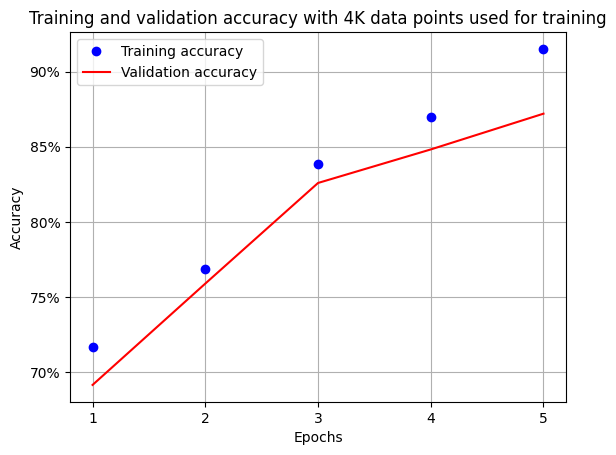

In [15]:
epochs = np.arange(5)+1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
plt.plot(epochs, train_accuracies, 'bo', label = 'Training accuracy') #pega acuracia de treino
plt.plot(epochs, val_accuracies, 'r', label = 'Validation accuracy') #pega a acuracia de teste
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with 4K data points used for training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid('off') #grafico q mostra acuracia de treino e de teste
plt.show()